##### Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

##### Load Data

In [3]:
df = pd.read_csv("baseball.csv")

##### Basic Info

In [4]:
# Top 5 rows
df.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424


In [5]:
# Shape
df.shape

(1232, 15)

In [6]:
# Columns
df.columns

Index(['Team', 'League', 'Year', 'RS', 'RA', 'W', 'OBP', 'SLG', 'BA',
       'Playoffs', 'RankSeason', 'RankPlayoffs', 'G', 'OOBP', 'OSLG'],
      dtype='object')

In [7]:
# Data types
df.dtypes

Team             object
League           object
Year              int64
RS                int64
RA                int64
W                 int64
OBP             float64
SLG             float64
BA              float64
Playoffs          int64
RankSeason      float64
RankPlayoffs    float64
G                 int64
OOBP            float64
OSLG            float64
dtype: object

In [8]:
# Statistical summary
df.describe()

,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,244.000000,244.000000,1232.000000,420.000000,420.000000
mean,1988.957792,715.081981,715.081981,80.904221,0.326331,0.397342,0.259273,0.198052,3.122951,2.717213,161.918831,0.332264,0.419743
std,14.819625,91.534294,93.079933,11.458139,0.015013,0.033267,0.012907,0.398693,1.738349,1.095234,0.624365,0.015295,0.026510
min,1962.000000,463.000000,472.000000,40.000000,0.277000,0.301000,0.214000,0.000000,1.000000,1.000000,158.000000,0.294000,0.346000
25%,1976.750000,652.000000,649.750000,73.000000,0.317000,0.375000,0.251000,0.000000,2.000000,2.000000,162.000000,0.321000,0.401000
50%,1989.000000,711.000000,709.000000,81.000000,0.326000,0.396000,0.260000,0.000000,3.000000,3.000000,162.000000,0.331000,0.419000
75%,2002.000000,775.000000,774.250000,89.000000,0.337000,0.421000,0.268000,0.000000,4.000000,4.000000,162.000000,0.343000,0.438000
max,2012.000000,1009.000000,1103.000000,116.000000,0.373000,0.491000,0.294000,1.000000,8.000000,5.000000,165.000000,0.384000,0.499000


##### Missing Value Analysis

In [9]:
# Missing values
df.isnull().sum()

Team              0
League            0
Year              0
RS                0
RA                0
W                 0
OBP               0
SLG               0
BA                0
Playoffs          0
RankSeason      988
RankPlayoffs    988
G                 0
OOBP            812
OSLG            812
dtype: int64

##### Drop Irrelevant Columns

In [10]:
# These are not suitable for imputation (logical missing)
df_clean = df.copy()

df_clean = df_clean.drop(columns=["RankSeason", "RankPlayoffs"])

df_clean.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,G,OOBP,OSLG
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,162,0.317,0.415
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,162,0.306,0.378
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,162,0.315,0.403
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,162,0.331,0.428
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,162,0.335,0.424


##### Duplicates

In [11]:
# Duplicates
print(df_clean.duplicated().sum())

0


##### KNN Imputation (for OOBP, OSLG)

In [12]:
num_cols = df_clean.select_dtypes(include=np.number).columns

imputer = KNNImputer(n_neighbors=5)
df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

# Missing after KNN imputation
df_clean.isnull().sum()

Team        0
League      0
Year        0
RS          0
RA          0
W           0
OBP         0
SLG         0
BA          0
Playoffs    0
G           0
OOBP        0
OSLG        0
dtype: int64

##### Outlier Detection (IQR)

In [13]:
def get_outliers(df):
    outliers = {}
    for col in df.select_dtypes(include=np.number).columns:
        
        # skip binary or constant columns
        if df[col].nunique() <= 2:
            continue
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        count = ((df[col] < lower) | (df[col] > upper)).sum()
        outliers[col] = int(count)
        
    return outliers

print("Outliers:")
print(get_outliers(df_clean))

Outliers:
{'Year': 0, 'RS': 10, 'RA': 9, 'W': 4, 'OBP': 9, 'SLG': 2, 'BA': 11, 'G': 278, 'OOBP': 4, 'OSLG': 3}


##### Outlier Treatment (Capping)

In [14]:
def cap_outliers(df):
    df_cap = df.copy()
    
    for col in df_cap.select_dtypes(include=np.number).columns:
        
        if df_cap[col].nunique() <= 2:
            continue
        
        Q1 = df_cap[col].quantile(0.25)
        Q3 = df_cap[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df_cap[col] = np.where(df_cap[col] < lower, lower, df_cap[col])
        df_cap[col] = np.where(df_cap[col] > upper, upper, df_cap[col])
    
    return df_cap

df_cap = cap_outliers(df_clean)

In [15]:
df_cap.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,G,OOBP,OSLG
0,ARI,NL,2012.0,734.0,688.0,81.0,0.328,0.418,0.259,0.0,162.0,0.317,0.415
1,ATL,NL,2012.0,700.0,600.0,94.0,0.320,0.389,0.247,1.0,162.0,0.306,0.378
2,BAL,AL,2012.0,712.0,705.0,93.0,0.311,0.417,0.247,1.0,162.0,0.315,0.403
3,BOS,AL,2012.0,734.0,806.0,69.0,0.315,0.415,0.260,0.0,162.0,0.331,0.428
4,CHC,NL,2012.0,613.0,759.0,61.0,0.302,0.378,0.240,0.0,162.0,0.335,0.424


In [16]:
# Statistical summary
df_cap.describe()

,Year,RS,RA,W,OBP,SLG,BA,Playoffs,G,OOBP,OSLG
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.0,1232.000000,1232.000000
mean,1988.957792,714.985390,714.869318,80.913149,0.326348,0.397345,0.259300,0.198052,162.0,0.326447,0.407311
std,14.819625,91.222339,92.405334,11.410504,0.014927,0.033253,0.012826,0.398693,0.0,0.014024,0.026533
min,1962.000000,467.500000,472.000000,49.000000,0.287000,0.306000,0.225500,0.000000,162.0,0.294000,0.346000
25%,1976.750000,652.000000,649.750000,73.000000,0.317000,0.375000,0.251000,0.000000,162.0,0.314600,0.388600
50%,1989.000000,711.000000,709.000000,81.000000,0.326000,0.396000,0.260000,0.000000,162.0,0.324400,0.406500
75%,2002.000000,775.000000,774.250000,89.000000,0.337000,0.421000,0.268000,0.000000,162.0,0.336000,0.426000
max,2012.000000,959.500000,961.000000,113.000000,0.367000,0.490000,0.293500,1.000000,162.0,0.368100,0.482100


##### Normalization (0-1)

In [18]:
df_norm = df_cap.copy()

for col in df_norm.select_dtypes(include=np.number).columns:
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())

In [19]:
df_norm.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,G,OOBP,OSLG
0,ARI,NL,1.0,0.541667,0.441718,0.500000,0.5125,0.608696,0.492647,0.0,NaN,0.310391,0.506980
1,ATL,NL,1.0,0.472561,0.261759,0.703125,0.4125,0.451087,0.316176,1.0,NaN,0.161943,0.235121
2,BAL,AL,1.0,0.496951,0.476483,0.687500,0.3000,0.603261,0.316176,1.0,NaN,0.283401,0.418810
3,BOS,AL,1.0,0.541667,0.683027,0.312500,0.3500,0.592391,0.507353,0.0,NaN,0.499325,0.602498
4,CHC,NL,1.0,0.295732,0.586912,0.187500,0.1875,0.391304,0.213235,0.0,NaN,0.553306,0.573108


##### Standardization (Z score)

In [20]:
df_std = df_cap.copy()

for col in df_std.select_dtypes(include=np.number).columns:
    df_std[col] = (df_std[col] - df_std[col].mean()) / df_std[col].std()

In [21]:
df_std.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,G,OOBP,OSLG
0,ARI,NL,1.554844,0.208442,-0.290777,0.007611,0.110654,0.621145,-0.023383,-0.496753,NaN,-0.673638,0.289781
1,ATL,NL,1.554844,-0.164273,-1.243103,1.146913,-0.425272,-0.250953,-0.958967,2.011441,NaN,-1.458023,-1.104685
2,BAL,AL,1.554844,-0.032727,-0.106805,1.059274,-1.028188,0.591073,-0.958967,2.011441,NaN,-0.816254,-0.162479
3,BOS,AL,1.554844,0.208442,0.986206,-1.044051,-0.760225,0.530928,0.054582,-0.496753,NaN,0.324670,0.779728
4,CHC,NL,1.554844,-1.117987,0.477577,-1.745160,-1.631105,-0.581748,-1.504725,-0.496753,NaN,0.609901,0.628975


##### Visualizations

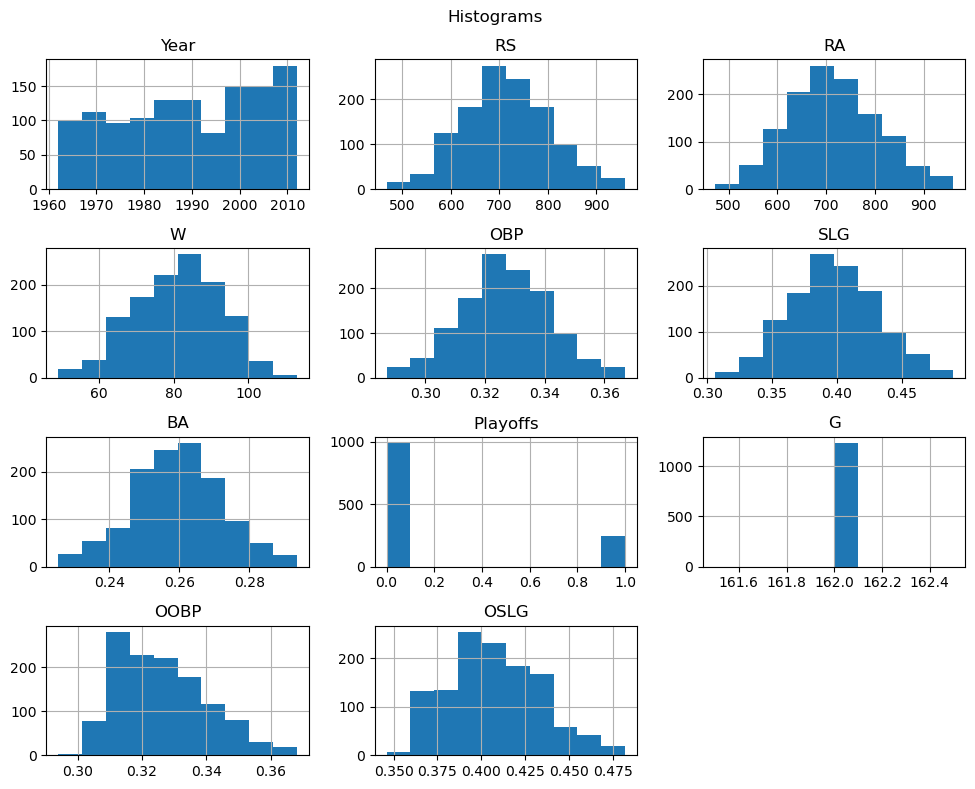

In [22]:
# Histogram
df_cap.hist(figsize=(10, 8))
plt.suptitle("Histograms")
plt.tight_layout()
plt.show()

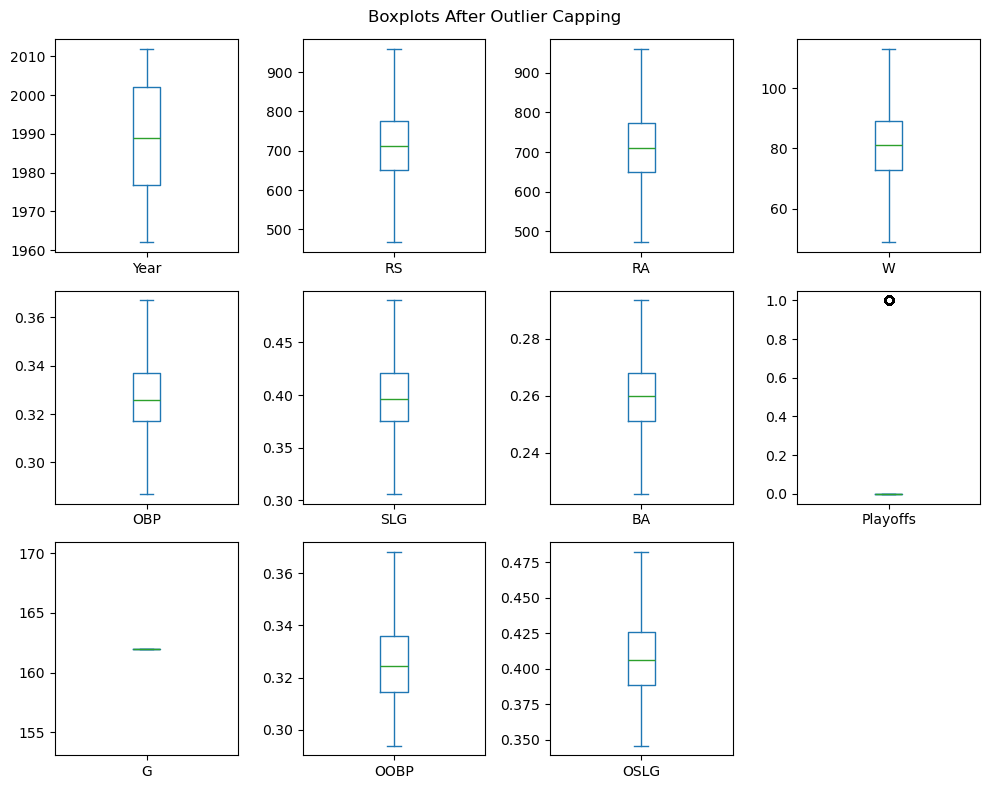

In [23]:
# Boxplot
df_cap.plot(kind='box', subplots=True, layout=(3,4), figsize=(10,8))
plt.suptitle("Boxplots After Outlier Capping")
plt.tight_layout()
plt.show()

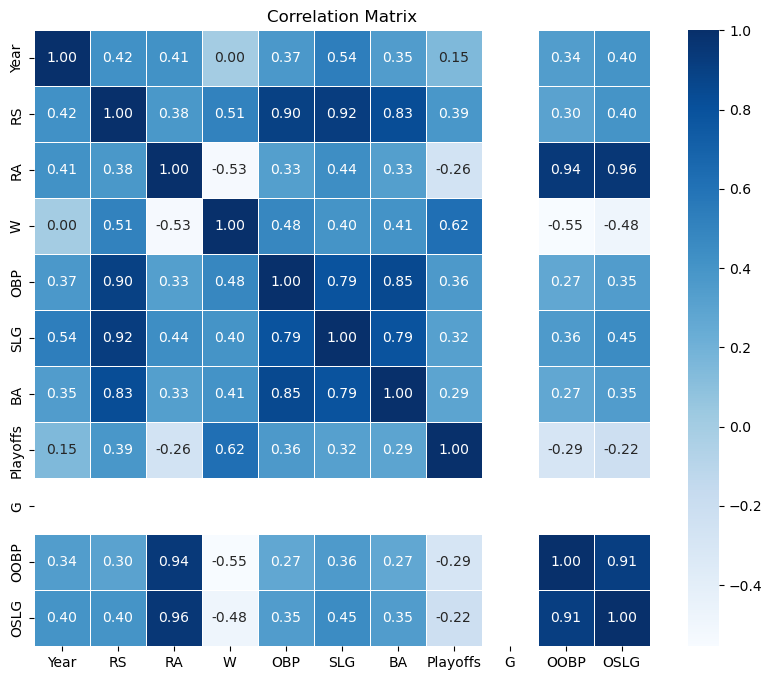

In [24]:
# Correlation
corr = df_cap.corr(numeric_only=True)
# print(corr)
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix")
plt.show()